# Exercise 7.5a Image segmentation with a U-Net architecture

In this exercise you train an image segmentation model from scratch on the Oxford Pets dataset.
https://www.robots.ox.ac.uk/~vgg/data/pets/

In [ ]:
import tensorflow as tf

# Configure GPU memory growth to prevent the 'Physical devices cannot be modified after being initialized' error.
# This should be done at the very beginning of your session, before any GPU operations.
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except RuntimeError as e:
        # This can happen if GPUs are already initialized by some other process/library
        print(f"Could not set GPU memory growth: {e}. GPU might already be initialized.")
else:
    print("No GPU devices found. Running on CPU.")

GPU memory growth enabled.


## Download the data

In [ ]:
import os
if(not os.path.exists("images.tar.gz")):
  !wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
if(not os.path.exists("annotations.tar.gz")):
  !wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
!tar -xf images.tar.gz
!tar -xf annotations.tar.gz

--2026-06-13 02:09:47--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-06-13 02:09:47--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz’

images.tar.gz       100%[===================>] 755.23M  9.10MB/s    in 6.7s    

2026-06-13 02:09:54 (113 MB/s) - ‘images.tar.gz’ saved [791918971/791918971]

--2026-06-13 02:09:54--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Resolving www.ro

## Prepare paths of input images and target segmentation masks

you don't need to touch the code below. It creates lists of the filenames to the images and segmentation maps.

In [ ]:
import os # Import the operating system module for path manipulation

# Define directories for input images and target segmentation masks
input_dir = "images/"
target_dir = "annotations/trimaps/"

# Define image processing parameters
img_size = (160, 160) # All images will be downscaled to this resolution
num_classes = 3      # Number of classes for segmentation (e.g., foreground, background, unclassified)
batch_size = 32      # Batch size for training the model

# Create a sorted list of paths to input images (JPEG files)
input_img_paths = sorted(
    [
        os.path.join(input_dir, fname) # Construct full path
        for fname in os.listdir(input_dir) # Iterate over files in the input directory
        if fname.endswith(".jpg") # Filter for JPEG image files
    ]
)

# Create a sorted list of paths to target segmentation masks (PNG files)
target_img_paths = sorted(
    [
        os.path.join(target_dir, fname) # Construct full path
        for fname in os.listdir(target_dir) # Iterate over files in the target directory
        if fname.endswith(".png") and not fname.startswith(".") # Filter for PNG files and exclude hidden files
    ]
)

print("Number of samples:", len(input_img_paths))

# Print the first 10 pairs of input image and target mask paths for verification
for input_path, target_path in zip(input_img_paths[:10], target_img_paths[:10]):
    print(input_path, "|", target_path)

Number of samples: 7390
images/Abyssinian_1.jpg | annotations/trimaps/Abyssinian_1.png
images/Abyssinian_10.jpg | annotations/trimaps/Abyssinian_10.png
images/Abyssinian_100.jpg | annotations/trimaps/Abyssinian_100.png
images/Abyssinian_101.jpg | annotations/trimaps/Abyssinian_101.png
images/Abyssinian_102.jpg | annotations/trimaps/Abyssinian_102.png
images/Abyssinian_103.jpg | annotations/trimaps/Abyssinian_103.png
images/Abyssinian_104.jpg | annotations/trimaps/Abyssinian_104.png
images/Abyssinian_105.jpg | annotations/trimaps/Abyssinian_105.png
images/Abyssinian_106.jpg | annotations/trimaps/Abyssinian_106.png
images/Abyssinian_107.jpg | annotations/trimaps/Abyssinian_107.png


## What does one input image and corresponding segmentation mask look like?
The codeblock below shows how you can display the images and the target segmentation mask. To reduce the computing load, we will downscale all images to a size of 160x160 pixels as defined above.
The goal of this task is to predict the segmentation mask as precisely as possible.

This example uses a few libraries to display and modify images (e.g. to rescale them to 160x160 pixels). The code below shows how these libraries can be used.

image number 2


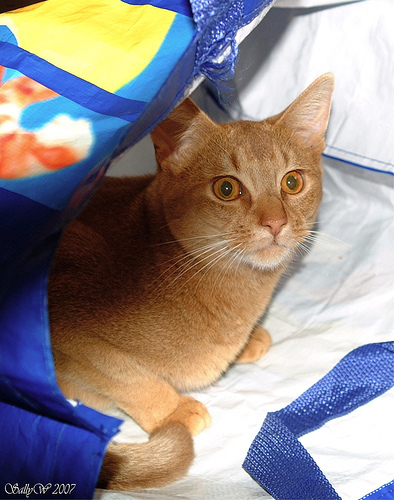

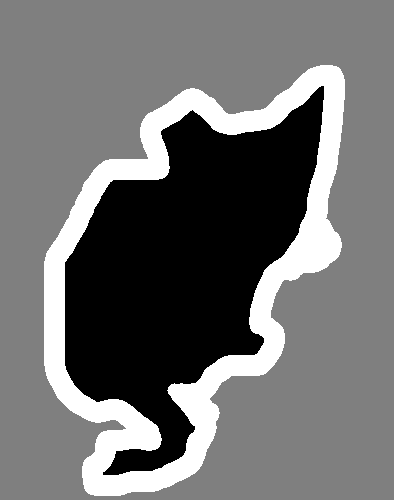

image number 2 downscaled.


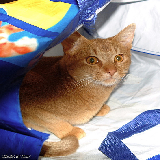

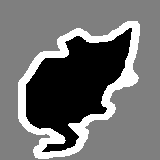

image number 7


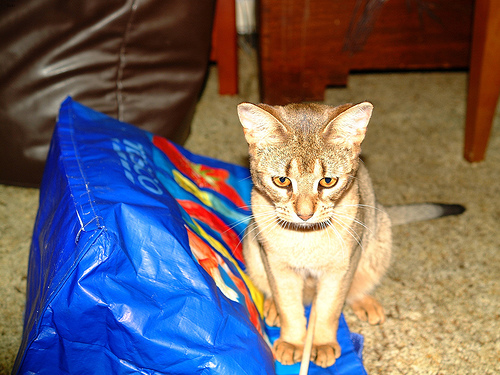

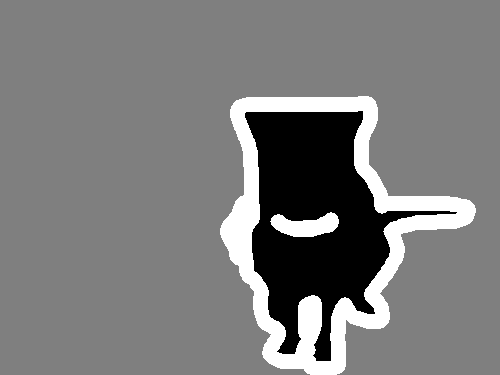

image number 7 downscaled.


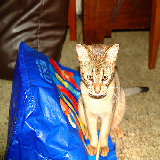

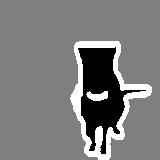

image number 3777


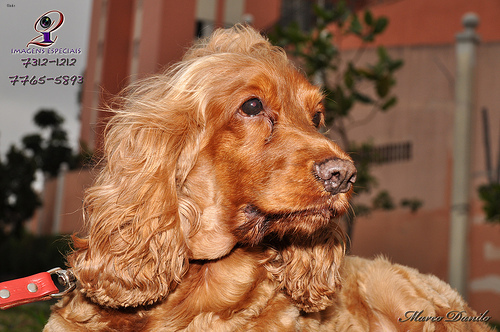

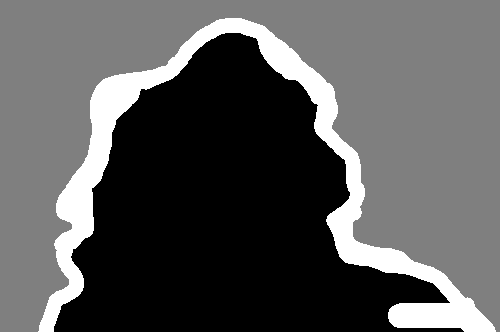

image number 3777 downscaled.


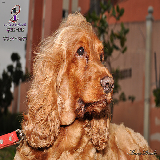

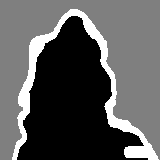

In [ ]:
from IPython.display import Image, display
from tensorflow.keras.preprocessing.image import load_img
import PIL
from PIL import ImageOps
import numpy as np

# Display input image #2 and #7
for i_sample in [2,7, 3777]:
  print(f"image number {i_sample}")
  display(Image(filename=input_img_paths[i_sample]))

  # Display auto-contrast version of corresponding target (per-pixel categories)
  # all pixels have either the value 1, 2 or 3:
  # 1: Foreground 2:Background 3: Not classified
  img =load_img(target_img_paths[i_sample])
  display(PIL.ImageOps.autocontrast(img)) # to properly display the image, we set an autocontrast (otherwise the values 1,2,3 would just all be black)

  print(f"image number {i_sample} downscaled.")
  # the task is done on a downscaled version of the image
  # the downscaling can be achieved by just passing a `targer_size` argument to the `load_img` function
  display(load_img(input_img_paths[i_sample], target_size=img_size))
  img = load_img(target_img_paths[i_sample], target_size=img_size)
  display(PIL.ImageOps.autocontrast(img))

## Prepare `Sequence` class to load & vectorize batches of data
You do not need to touch the codeblock below. It is a helper class that returns batches of images and their target masks in the downscaled version. This is an alternative way to provide the training and validation data to the KERAS fit function. A large library of images are typically too big too keep them all in memory. Instead, a so-called "generator" function returns a new batch of images everytime it is called. This is implemented below. When the `__get_item(idx)` method is called, it loads all images from batch `idx` into memory and returns it as a NumPy array.
The `__len__` method returns how many batches are in one epoch.

In [ ]:
from tensorflow import keras
import numpy as np
from tensorflow.keras.preprocessing.image import load_img


class OxfordPets(keras.utils.Sequence):
    """Helper to iterate over the data (as Numpy arrays)."""

    def __init__(self, batch_size, img_size, input_img_paths, target_img_paths):
        self.batch_size = batch_size
        self.img_size = img_size
        self.input_img_paths = input_img_paths
        self.target_img_paths = target_img_paths

    def __len__(self):
        return len(self.target_img_paths) // self.batch_size

    def __getitem__(self, idx):
        """Returns tuple (input, target) correspond to batch #idx."""
        i = idx * self.batch_size
        batch_input_img_paths = self.input_img_paths[i : i + self.batch_size]
        batch_target_img_paths = self.target_img_paths[i : i + self.batch_size]
        x = np.zeros((self.batch_size,) + self.img_size + (3,), dtype="float32")
        for j, path in enumerate(batch_input_img_paths):
            img = load_img(path, target_size=self.img_size)
            x[j] = img
        y = np.zeros((self.batch_size,) + self.img_size + (1,), dtype="uint8")
        for j, path in enumerate(batch_target_img_paths):
            img = load_img(path, target_size=self.img_size, color_mode="grayscale")
            y[j] = np.expand_dims(img, 2) # one hot encoding:
            # Ground truth labels are 1, 2, 3. Subtract one to make them 0, 1, 2:
            # i.e. background is 0, foreground (the animal) is 1, and unclassified is 3 (the contour around the animal)
            y[j] -= 1
        return x, y


## Prepare U-Net model

Hints:
* The final layer should have three feature maps with a softmax activation. This is because we want to predict the segmentation mask wich has three possible values: 0, 1, 2. The softmax activation works on each pixel, i.e., per pixel, the values of the feature maps add up to 1. Per pixel, the feature map with the highest propability indicates if we have "background", "foreground" or "unclassified". By using the `numpy.argmax` function, we can get back the integer for plotting the mask later (see `display_mask` function defined curther below).
* instead of using standard convolutions you can use `SeparableConv2D` to reduce the number of trainable parameters
* layers `x` and `x2` can be concacenated via `x = layers.concatenate([x, x2])`
* upsampling can be done with `x = layers.UpSampling2D(2)(x)`
* Always use `padding="same"` to kee the spatial dimension constant


In [ ]:
from tensorflow.keras import layers
from tensorflow import keras # Import keras for Model and Input
# Free up RAM in case the model definition cells were run multiple times
keras.backend.clear_session()


# Define the input layer for the U-Net model
inputs = keras.Input(shape=img_size + (3,))

### [First half of the network: downsampling inputs (Encoder)] ###

# Entry block (Downsampling Block 1)
# Two separable convolutional layers followed by Batch Normalization and ReLU activation
x = layers.SeparableConv2D(32, 3, padding="same")(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.SeparableConv2D(32, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
conv1 = layers.Activation("relu")(x) # Store for skip connection
x = layers.MaxPooling2D(2)(conv1) # Downsample by 2x2 max pooling

# Downsampling Block 2
x = layers.SeparableConv2D(64, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.SeparableConv2D(64, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
conv2 = layers.Activation("relu")(x) # Store for skip connection
x = layers.MaxPooling2D(2)(conv2)

# Downsampling Block 3
x = layers.SeparableConv2D(128, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.SeparableConv2D(128, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
conv3 = layers.Activation("relu")(x) # Store for skip connection
x = layers.MaxPooling2D(2)(conv3)

# Downsampling Block 4
x = layers.SeparableConv2D(256, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.SeparableConv2D(256, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
conv4 = layers.Activation("relu")(x) # Store for skip connection
x = layers.MaxPooling2D(2)(conv4)

### [Bottleneck (Bridge between Encoder and Decoder)] ###
# Two separable convolutional layers for feature extraction at the deepest level
x = layers.SeparableConv2D(512, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.SeparableConv2D(512, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

### [Second half of the network: upsampling outputs (Decoder)] ###

# Upsampling Block 1
x = layers.UpSampling2D(2)(x) # Upsample to match conv4 resolution
x = layers.concatenate([x, conv4]) # Concatenate with skip connection from Downsampling Block 4
x = layers.SeparableConv2D(256, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.SeparableConv2D(256, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

# Upsampling Block 2
x = layers.UpSampling2D(2)(x) # Upsample to match conv3 resolution
x = layers.concatenate([x, conv3]) # Concatenate with skip connection from Downsampling Block 3
x = layers.SeparableConv2D(128, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.SeparableConv2D(128, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

# Upsampling Block 3
x = layers.UpSampling2D(2)(x) # Upsample to match conv2 resolution
x = layers.concatenate([x, conv2]) # Concatenate with skip connection from Downsampling Block 2
x = layers.SeparableConv2D(64, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.SeparableConv2D(64, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

# Upsampling Block 4
x = layers.UpSampling2D(2)(x) # Upsample to match conv1 resolution
x = layers.concatenate([x, conv1]) # Concatenate with skip connection from Downsampling Block 1
x = layers.SeparableConv2D(32, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.SeparableConv2D(32, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

# Add a per-pixel classification layer
# Final 1x1 convolution with softmax activation for multi-class segmentation
outputs = layers.Conv2D(num_classes, 3, activation="softmax", padding="same")(x)

# Define the Keras model with inputs and outputs
model = keras.Model(inputs, outputs)

# Display a summary of the model's architecture
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 160, 160,  │        155 │ input_layer[0][0] │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 160, 160,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 160, 160,  │      1,344 │ activation[0][0]  │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 80, 80,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 80, 80,    │      2,400 │ max_pooling2d[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_3  │ (None, 80, 80,    │      4,736 │ activation_2[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 40, 40,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_4  │ (None, 40, 40,    │      8,896 │ max_pooling2d_1[… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 40,    │        512 │ separable_conv2d

 Total params: 917,662 (3.50 MB)

 Trainable params: 911,774 (3.48 MB)

 Non-trainable params: 5,888 (23.00 KB)

## Set aside a validation split

In [ ]:
import random # Import the random module for shuffling data

# Define the number of samples to be used for validation
val_samples = 1000

# Shuffle the input and target image paths consistently using a fixed seed for reproducibility
random.Random(1337).shuffle(input_img_paths)
random.Random(1337).shuffle(target_img_paths)

# Split the shuffled image paths into training sets (all but the last `val_samples`)
train_input_img_paths = input_img_paths[:-val_samples]
train_target_img_paths = target_img_paths[:-val_samples]

# Split the shuffled image paths into validation sets (the last `val_samples`)
val_input_img_paths = input_img_paths[-val_samples:]
val_target_img_paths = target_img_paths[-val_samples:]

# Instantiate data Sequences (generators) for the training set
train_gen = OxfordPets(
    batch_size, img_size, train_input_img_paths, train_target_img_paths
)

# Instantiate data Sequences (generators) for the validation set
val_gen = OxfordPets(batch_size, img_size, val_input_img_paths, val_target_img_paths)

## Train the model

In [ ]:
import tensorflow as tf
from tensorflow import keras # Import keras for ModelCheckpoint

# Configure the model for training.
# We use the "sparse" version of categorical_crossentropy
# because our target data is integers.
model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

callbacks = [
    keras.callbacks.ModelCheckpoint("oxford_segmentation.keras", save_best_only=True)
]

# Initialize epochs and history variables outside the conditional blocks
epochs = None
history = None

# Check for GPU devices and train on GPU if available
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth needs to be set before GPUs are initialized
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
        with tf.device('/GPU:0'):
            # Train the model, doing validation at the end of each epoch.
            epochs = 20
            history = model.fit(train_gen, epochs=epochs, validation_data=val_gen, callbacks=callbacks)
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU devices found. Training on CPU.")
    # Train the model, doing validation at the end of each epoch.
    epochs = 15
    history = model.fit(train_gen, epochs=epochs, validation_data=val_gen, callbacks=callbacks)


1 Physical GPUs, 1 Logical GPUs


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 78s 250ms/step - accuracy: 0.7660 - loss: 0.5774 - val_accuracy: 0.5842 - val_loss: 0.9437
Epoch 2/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 42s 209ms/step - accuracy: 0.8345 - loss: 0.4219 - val_accuracy: 0.5894 - val_loss: 1.1367
Epoch 3/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 43s 216ms/step - accuracy: 0.8543 - loss: 0.3732 - val_accuracy: 0.8450 - val_loss: 0.3978
Epoch 4/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 42s 210ms/step - accuracy: 0.8666 - loss: 0.3410 - val_accuracy: 0.8537 - val_loss: 0.3848
Epoch 5/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 41s 207ms/step - accuracy: 0.8761 - loss: 0.3164 - val_accuracy: 0.8493 - val_loss: 0.3910
Epoch 6/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 42s 209ms/step - accuracy: 0.8840 - loss: 0.2962 - val_accuracy: 0.8242 - val_loss: 0.5369
Epoch 7/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 43s 213ms/step - accuracy: 0.8921 - loss: 0.2755 - val_accuracy: 0.8719 - val_loss: 0.3441
Epoch 8/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 42s 208ms/step - accuracy: 0.8977 - loss: 0

## Plot Training and Validation Loss Curves

Visualizing the training and validation loss curves helps us understand if the model is overfitting, underfitting, or learning effectively.

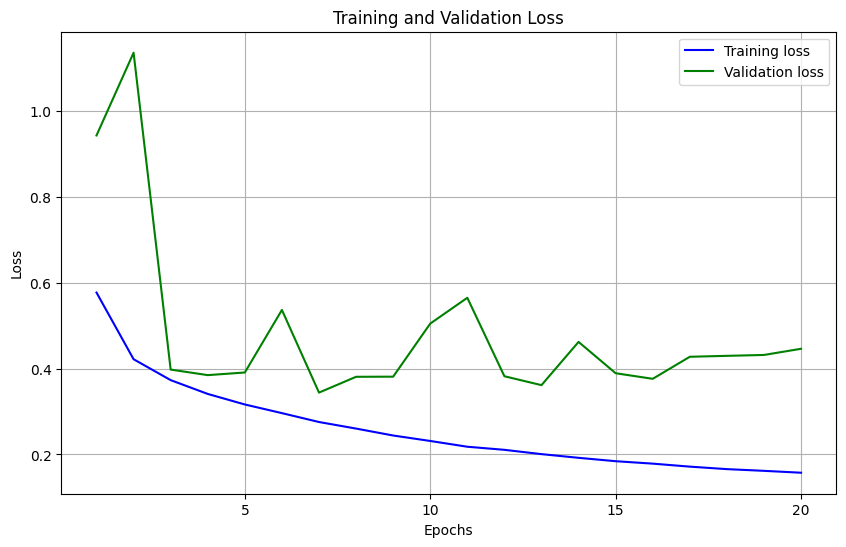

In [ ]:
import matplotlib.pyplot as plt

# Get the loss and validation loss from the history object obtained during training
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(loss) + 1)

# Plot the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, loss, 'b-', label='Training loss')
plt.plot(epochs_range, val_loss, '-', label='Validation loss', color="g")
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.locator_params(axis='x', integer=True) # Ensure x-axis ticks are integers
plt.show()

The gap between training and validation loss is moderate. There is a sign of overfitting. However, generally model shows good training as both losses tend to decrease. The validation loss is decreasing until epoch 10 or so. However, the performance tends to decline with increasing epochs as model tends to overfit. Hence, more epochs arent helping the network learn anything better.

## Visualize predictions

In [ ]:
# Generate predictions for all images in the validation set
model.load_weights("oxford_segmentation.keras") # the last iteration might not be the best. So load back the best version
val_gen = OxfordPets(batch_size, img_size, val_input_img_paths, val_target_img_paths)
val_preds = model.predict(val_gen)


def display_mask(i):
    """Quick utility to display a model's prediction."""
    mask = np.argmax(val_preds[i], axis=-1) # find which feature map has the highest value per pixel -> this gives back the category 0, 1, or 2
    mask = np.expand_dims(mask, axis=-1) # The image plotting library requires that the color of the image is given as an array (in our case it is just one number, but for color images we would have three color channels)
    img = PIL.ImageOps.autocontrast(keras.preprocessing.image.array_to_img(mask))
    display(img)


31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step


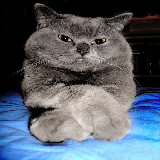

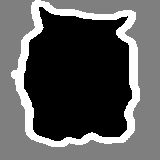

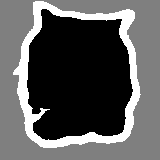

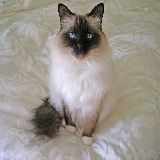

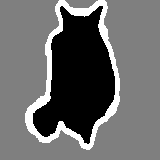

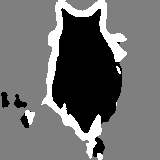

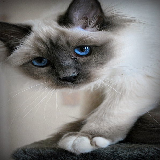

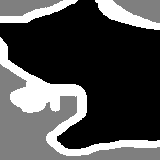

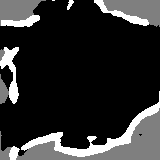

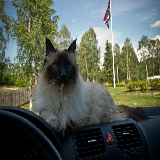

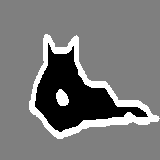

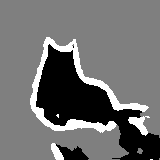

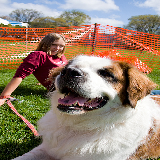

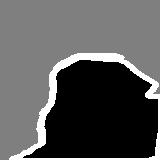

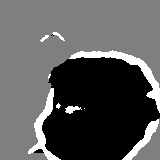

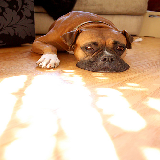

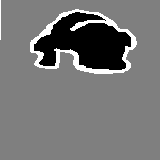

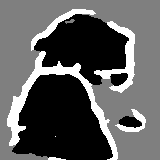

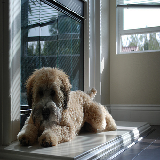

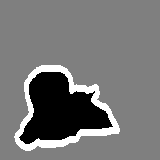

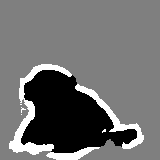

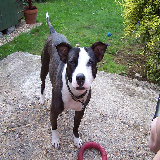

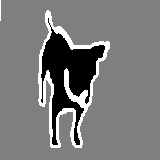

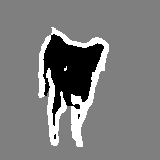

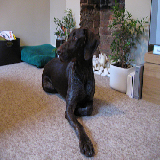

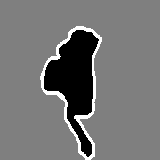

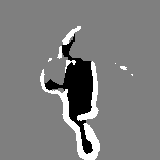

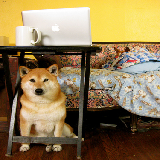

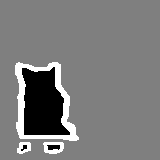

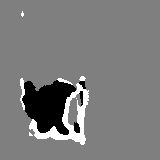

In [ ]:
# Display results for validation image #10
for i in range(10):

  # Display input image
  display(load_img(val_input_img_paths[i], target_size=img_size))

  # Display ground-truth target mask
  img = PIL.ImageOps.autocontrast(load_img(val_target_img_paths[i], target_size=img_size))
  display(img)

  # Display mask predicted by our model
  display_mask(i)  # Note that the model only sees inputs at 160x160.

It can be seen that the model performed well on some images and just bearable on others. For example, the last image shown above, is asking for justice for cutting the head off. However, model was able to detect the forground and background in these images very well. Confusion matrix and IoU will reveal where the model struggled the most.

## Calculate Mean Intersection-over-Union (mIoU) score

The Intersection-over-Union (IoU) is a common metric for evaluating the performance of image segmentation models. It quantifies the overlap between the predicted segmentation mask and the ground truth mask for each class. The mean IoU (mIoU) is the average of the IoU scores across all classes.

$IoU = \frac{\text{Area of Overlap}}{\text{Area of Union}} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives} + \text{False Negatives}}$

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img

def calculate_iou(y_true, y_pred, num_classes):
    iou_scores = []
    for class_id in range(num_classes):
        true_class_mask = (y_true == class_id).astype(int)
        pred_class_mask = (y_pred == class_id).astype(int)

        intersection = np.sum(true_class_mask * pred_class_mask)
        union = np.sum(true_class_mask) + np.sum(pred_class_mask) - intersection

        if union == 0:
            iou = 1.0 if intersection == 0 else 0.0 # If both are empty, consider perfect overlap. Otherwise, no overlap.
        else:
            iou = intersection / union
        iou_scores.append(iou)
    return iou_scores

# Get ground truth masks for the validation set
# We need to recreate how the masks are processed in OxfordPets __getitem__
val_target_masks = []
for path in val_target_img_paths:
    img = load_img(path, target_size=img_size, color_mode="grayscale")
    mask = np.expand_dims(img, 2) # Add channel dimension
    mask = mask.astype('uint8') - 1 # Ground truth labels are 1, 2, 3. Subtract one to make them 0, 1, 2
    val_target_masks.append(mask)

val_target_masks = np.array(val_target_masks)

# Convert predictions to hard masks (0, 1, or 2)
val_predicted_masks = np.argmax(val_preds, axis=-1)
val_predicted_masks = np.expand_dims(val_predicted_masks, axis=-1)


all_iou_scores = []
# Iterate only up to the number of available predictions
for i in range(len(val_predicted_masks)):
    iou_per_class = calculate_iou(
        val_target_masks[i],
        val_predicted_masks[i],
        num_classes
    )
    all_iou_scores.append(iou_per_class)

# Calculate mean IoU per class
mean_iou_per_class = np.mean(all_iou_scores, axis=0)

print(f"Mean IoU per class (0=Background, 1=Foreground, 2=Unclassified): {mean_iou_per_class}")
print(f"Overall Mean IoU (mIoU): {np.mean(mean_iou_per_class)}")


Mean IoU per class (0=Background, 1=Foreground, 2=Unclassified): [0.73950471 0.853263   0.43839049]
Overall Mean IoU (mIoU): 0.6770527329496133


The model gets IoU the highest for Foreground (0.8534), Background (0.7523) and the least for (0.43289). These values reflects strong overlap between predicted masks and true masks (animal and background). However, the unclassified category got the least IoU. This is the lowest IoU score among the three classes. The 'Unclassified' class represents the boundaries or regions that are neither clearly foreground nor background (e.g., the thin border around the animal in the trimaps). A lower score here means the model struggles more with precisely identifying these ambiguous regions. It has a harder time accurately capturing the extent of these unclassified areas, leading to more false positives and false negatives for this specific class.

**Overall Mean IoU (mIoU): 0.6796:** This is the average of the IoU scores across all three classes. It provides a single summary metric of your model's overall segmentation performance. An mIoU of 0.68 is a decent performance, but the lower score for the 'Unclassified' class pulls down the overall average. Improving the model's ability to segment the 'Unclassified' regions would significantly boost this overall score.

## Identify and Display Worst-Performing Samples

Let's visualize some of the images where the model performed poorly (lowest IoU scores) to understand the failure modes.

Displaying the 5 worst-performing validation samples based on IoU:

Sample Index: 965, Mean IoU: 0.1460
  IoU per category: Background=0.1528, Foreground=0.2255, Unclassified=0.0599
Input Image:


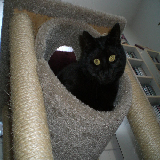

Ground Truth Mask:


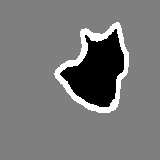

Predicted Mask:


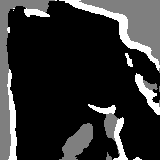


Sample Index: 405, Mean IoU: 0.1639
  IoU per category: Background=0.0485, Foreground=0.3753, Unclassified=0.0678
Input Image:


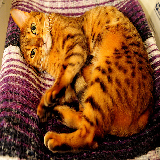

Ground Truth Mask:


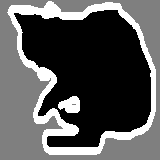

Predicted Mask:


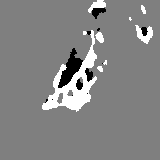


Sample Index: 927, Mean IoU: 0.1677
  IoU per category: Background=0.0532, Foreground=0.1752, Unclassified=0.2748
Input Image:


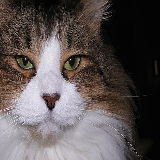

Ground Truth Mask:


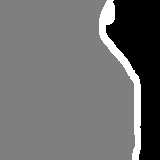

Predicted Mask:


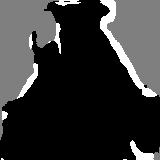


Sample Index: 280, Mean IoU: 0.1981
  IoU per category: Background=0.0000, Foreground=0.5942, Unclassified=0.0000
Input Image:


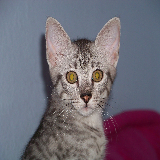

Ground Truth Mask:


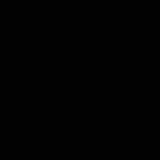

Predicted Mask:


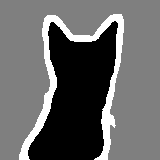


Sample Index: 699, Mean IoU: 0.2067
  IoU per category: Background=0.0000, Foreground=0.6202, Unclassified=0.0000
Input Image:


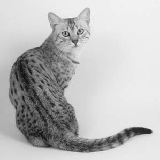

Ground Truth Mask:


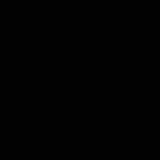

Predicted Mask:


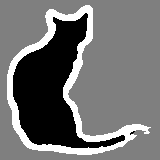

In [ ]:
# Calculate the mean IoU for each sample
sample_mean_iou = np.array([np.mean(scores) for scores in all_iou_scores])

# Get the indices of the worst-performing samples (lowest IoU)
# Let's say we want to see the 5 worst samples
num_worst_samples = 5
worst_sample_indices = np.argsort(sample_mean_iou)[:num_worst_samples]

print(f"Displaying the {num_worst_samples} worst-performing validation samples based on IoU:")
for i_sample in worst_sample_indices:
    print(f"\nSample Index: {i_sample}, Mean IoU: {sample_mean_iou[i_sample]:.4f}")
    # Print individual IoU per category
    iou_scores_individual = all_iou_scores[i_sample]
    print(f"  IoU per category: Background={iou_scores_individual[0]:.4f}, Foreground={iou_scores_individual[1]:.4f}, Unclassified={iou_scores_individual[2]:.4f}")

    # Display input image
    print("Input Image:")
    display(load_img(val_input_img_paths[i_sample], target_size=img_size))

    # Display ground-truth target mask
    print("Ground Truth Mask:")
    img = PIL.ImageOps.autocontrast(load_img(val_target_img_paths[i_sample], target_size=img_size))
    display(img)

    # Display mask predicted by our model
    print("Predicted Mask:")
    display_mask(i_sample)


Image 280 and 699 shows one of the worst-performing validation samples, with a very less mean IoU. Since the mean IoU is computed by averaging the IoU values of all three classes (background, foreground, and boundary), errors across multiple classes contribute to the extremely low score. As IoU for two categories was zero, which pulled the mean to extremely low value. This example illustrates a common limitation of semantic segmentation models. Also, for image 280, and 699, its wierd to see that in truth masks, the whole image is masked as foreground, when visually the image isnt.


## Visualize a High-Performing Sample

Let's also visualize a sample where the model performed exceptionally well (high IoU scores) to see its ideal performance.

Displaying the 5 best-performing validation samples based on IoU:

Sample Index: 483, Mean IoU: 0.8777
  IoU per category: Background=0.9497, Foreground=0.9568, Unclassified=0.7267
Input Image:


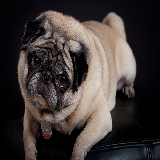

Ground Truth Mask:


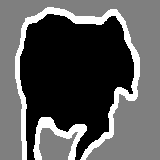

Predicted Mask:


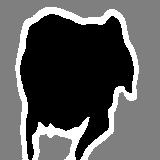


Sample Index: 977, Mean IoU: 0.8778
  IoU per category: Background=0.9149, Foreground=0.9875, Unclassified=0.7311
Input Image:


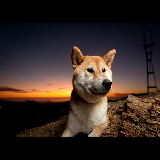

Ground Truth Mask:


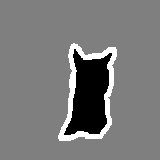

Predicted Mask:


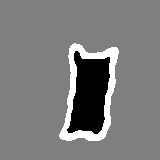


Sample Index: 275, Mean IoU: 0.8785
  IoU per category: Background=0.9528, Foreground=0.9780, Unclassified=0.7046
Input Image:


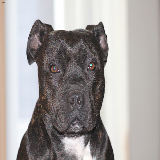

Ground Truth Mask:


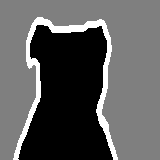

Predicted Mask:


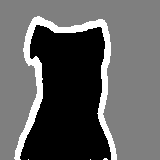


Sample Index: 695, Mean IoU: 0.8869
  IoU per category: Background=0.9616, Foreground=0.9774, Unclassified=0.7217
Input Image:


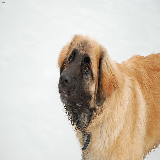

Ground Truth Mask:


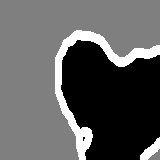

Predicted Mask:


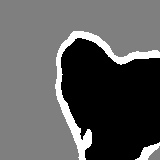


Sample Index: 56, Mean IoU: 0.8980
  IoU per category: Background=0.9354, Foreground=0.9910, Unclassified=0.7677
Input Image:


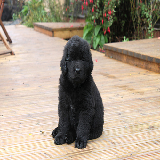

Ground Truth Mask:


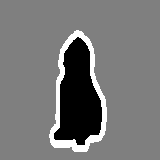

Predicted Mask:


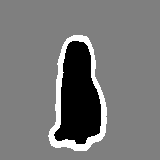

In [ ]:
# Get the indices of the best-performing samples (highest IoU)
# Let's say we want to see the best sample
num_best_samples = 5
best_sample_indices = np.argsort(sample_mean_iou)[-num_best_samples:]

print(f"Displaying the {num_best_samples} best-performing validation samples based on IoU:")
for i_sample in best_sample_indices:
    print(f"\nSample Index: {i_sample}, Mean IoU: {sample_mean_iou[i_sample]:.4f}")
    # Print individual IoU per category
    iou_scores_individual = all_iou_scores[i_sample]
    print(f"  IoU per category: Background={iou_scores_individual[0]:.4f}, Foreground={iou_scores_individual[1]:.4f}, Unclassified={iou_scores_individual[2]:.4f}")

    # Display input image
    print("Input Image:")
    display(load_img(val_input_img_paths[i_sample], target_size=img_size))

    # Display ground-truth target mask
    print("Ground Truth Mask:")
    img = PIL.ImageOps.autocontrast(load_img(val_target_img_paths[i_sample], target_size=img_size))
    display(img)

    # Display mask predicted by our model
    print("Predicted Mask:")
    display_mask(i_sample)


Well done I say!

## Plot Confusion Matrix

A confusion matrix provides a detailed breakdown of correct and incorrect classifications for each class, giving insights into class-wise misclassification patterns.

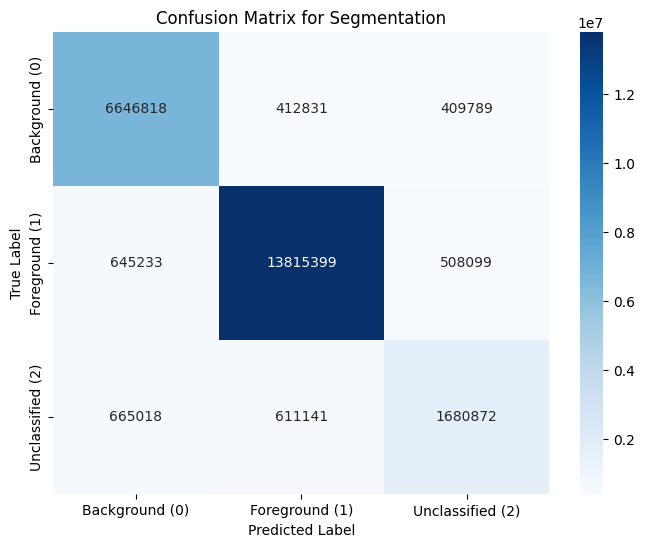

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Reshape true and predicted masks to 1D arrays for confusion matrix calculation
# Exclude the channel dimension if it's 1
y_true_flat = val_target_masks[:len(val_predicted_masks)].flatten()
y_pred_flat = val_predicted_masks.flatten()

# Ensure both arrays have the same length
min_len = min(len(y_true_flat), len(y_pred_flat))
y_true_flat = y_true_flat[:min_len]
y_pred_flat = y_pred_flat[:min_len]

# Calculate confusion matrix
# Labels are 0 (Background), 1 (Foreground), 2 (Unclassified)
cm = confusion_matrix(y_true_flat, y_pred_flat, labels=range(num_classes))

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Background (0)', 'Foreground (1)', 'Unclassified (2)'],
            yticklabels=['Background (0)', 'Foreground (1)', 'Unclassified (2)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Segmentation')
plt.show()


The confusion matrix provides a pixel-level breakdown of the model's classification performance across the three classes:

*   **Background (0):**
    *   The model correctly identified **6,646,818 pixels** as background. This is a very high number, indicating strong performance for this class.
    *   It misclassified a significant number of background pixels as 'Foreground' (412,831) and 'Unclassified' (409,789), which could be due to edges or textured background elements being confused with foreground features.

*   **Foreground (1):**
    *   The model correctly identified **13,815,399 pixels** as foreground. This is also a strong performance for the main object.
    *   It misclassified a notable number of foreground pixels as 'Background' (645,233) and 'Unclassified' (508,099). This suggests that some parts of the animal might be missed or confused with surrounding elements.

*   **Unclassified (2):**
    *   The model correctly identified **1,680,872 pixels** as 'Unclassified'. This is a much lower number compared to the other classes, and it also has a significant number of misclassifications.
    *   A large number of 'Unclassified' pixels were misclassified as 'Background' (665,018) and 'Foreground' (611,141). This strongly confirms our earlier observation from the IoU scores: the model struggles most with the 'Unclassified' regions, which are typically the thin boundaries between the foreground and background. It frequently assigns these ambiguous pixels to either the foreground or background classes.

**Overall Takeaways:**

*   The model performs very well on distinguishing large areas of **Background** and **Foreground**.
*   Its primary weakness lies in accurately segmenting the **Unclassified** regions, which are often the challenging edges and boundaries. This leads to these pixels being frequently mislabeled as either background or foreground. Addressing this could significantly improve the overall mIoU.

In [ ]:
pixel_wise_accuracy = np.sum(np.diag(cm)) / np.sum(cm)
print(f"Pixel-wise Accuracy: {pixel_wise_accuracy:.4f}")

Pixel-wise Accuracy: 0.8719


The pixel-wise accuracy has been calculated as 0.8719. This means that approximately 87.19% of all pixels in the validation set were correctly classified by the model across all three classes (Background, Foreground, Unclassified). This high accuracy aligns with what we observed in the confusion matrix, where the diagonal values (correct classifications) are significantly larger than the off-diagonal values (misclassifications).



### Overall, The U-Net model demonstrates strong performance in segmenting large areas of 'Background' and 'Foreground'. However, its primary challenge lies in accurately segmenting the 'Unclassified' regions, which are often the ambiguous boundaries between foreground and background. Improving performance on these 'Unclassified' areas would further enhance the model's overall mean IoU.

